# 03 — EDA e Visualizações
**Projeto: Data Science dos Santos Católicos**

Este é o notebook principal de análise exploratória. Vamos criar **13 gráficos** que revelam padrões históricos, geográficos e estatísticos nos dados dos santos.

| # | Gráfico | Biblioteca |
|---|---|---|
| 1 | Mapa coroplético mundial | plotly |
| 2 | Bar chart: Top 20 países | seaborn |
| 3 | Time series: santos por século | matplotlib |
| 4 | Stacked bar: categorias por século | matplotlib |
| 5 | Heatmap: século × continente | seaborn |
| 6 | Violin plot: anos até canonização | seaborn |
| 7 | Box plot: anos por continente | seaborn |
| 8 | Scatter: morte × canonização | matplotlib |
| 9 | Treemap: ordens religiosas | plotly |
| 10 | Bar chart: patronatos mais comuns | matplotlib |
| 11 | Polar chart: festas por mês | matplotlib |
| 12 | Correlation heatmap | seaborn |
| 13 | Pair plot | seaborn |

## Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
FIGS         = PROJECT_ROOT / 'outputs' / 'figures'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})
sns.set_theme(style='whitegrid', palette='muted')

CORES = {
    'Martyr':    '#C0392B',
    'Confessor': '#2980B9',
    'Doctor':    '#F39C12',
    'Virgin':    '#8E44AD',
    'Other':     '#95A5A6',
}

df = pd.read_csv(DATA_PROC / 'saints_clean.csv')
print(f'Dataset carregado: {df.shape}')
df.head(3)

Dataset carregado: (77, 19)


,name,gender,death_year,canonization_year,years_to_canonization,century_of_death,origin_country,continent,category,is_martyr,is_doctor,is_virgin,is_ancient_canonization,religious_order,feast_month,patron_topics,num_patron_topics,canonizing_pope,wikipedia_summary
0,Peter the Apostle,M,68,1000,932.0,1,Palestine,Asia,Martyr,True,False,False,True,NaN,NaN,"fishermen, papacy",2,Pre-Congregation,Saint Peter (born Shimon bar Yonah; 1 BC – AD ...
1,Paul the Apostle,M,67,1000,933.0,1,Turkey,Asia,Martyr,True,False,False,True,NaN,NaN,"missionaries, theologians",2,Pre-Congregation,Paul (born Saul of Tarsus; c. 5 – c. 64/65 AD)...
2,Stephen,M,36,1000,964.0,1,Palestine,Asia,Martyr,True,False,False,True,NaN,NaN,"deacons, stonemasons",2,Pre-Congregation,Stephen or Steven is an English male first nam...


---
## Gráfico 1 — Mapa Mundial de Santos por País

C:\Users\mateu\AppData\Local\Temp\ipykernel_36472\1867373266.py:4: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


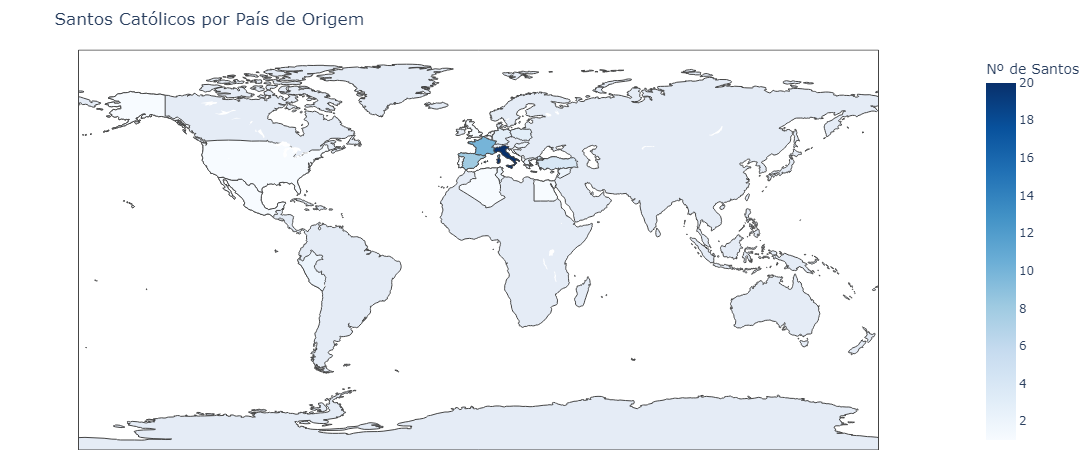

Europa domina — Itália, França e Espanha lideram.


In [2]:
por_pais = df['origin_country'].value_counts().reset_index()
por_pais.columns = ['country', 'count']

fig = px.choropleth(
    por_pais,
    locations='country',
    locationmode='country names',
    color='count',
    color_continuous_scale='Blues',
    title='Santos Católicos por País de Origem',
    labels={'count': 'Nº de Santos'},
)
fig.update_layout(height=450, margin=dict(l=0, r=0, t=50, b=0))
fig.write_html(str(FIGS / '03_mapa_paises.html'))
fig.show()
print('Europa domina — Itália, França e Espanha lideram.')

---
## Gráfico 2 — Top 20 Países de Origem

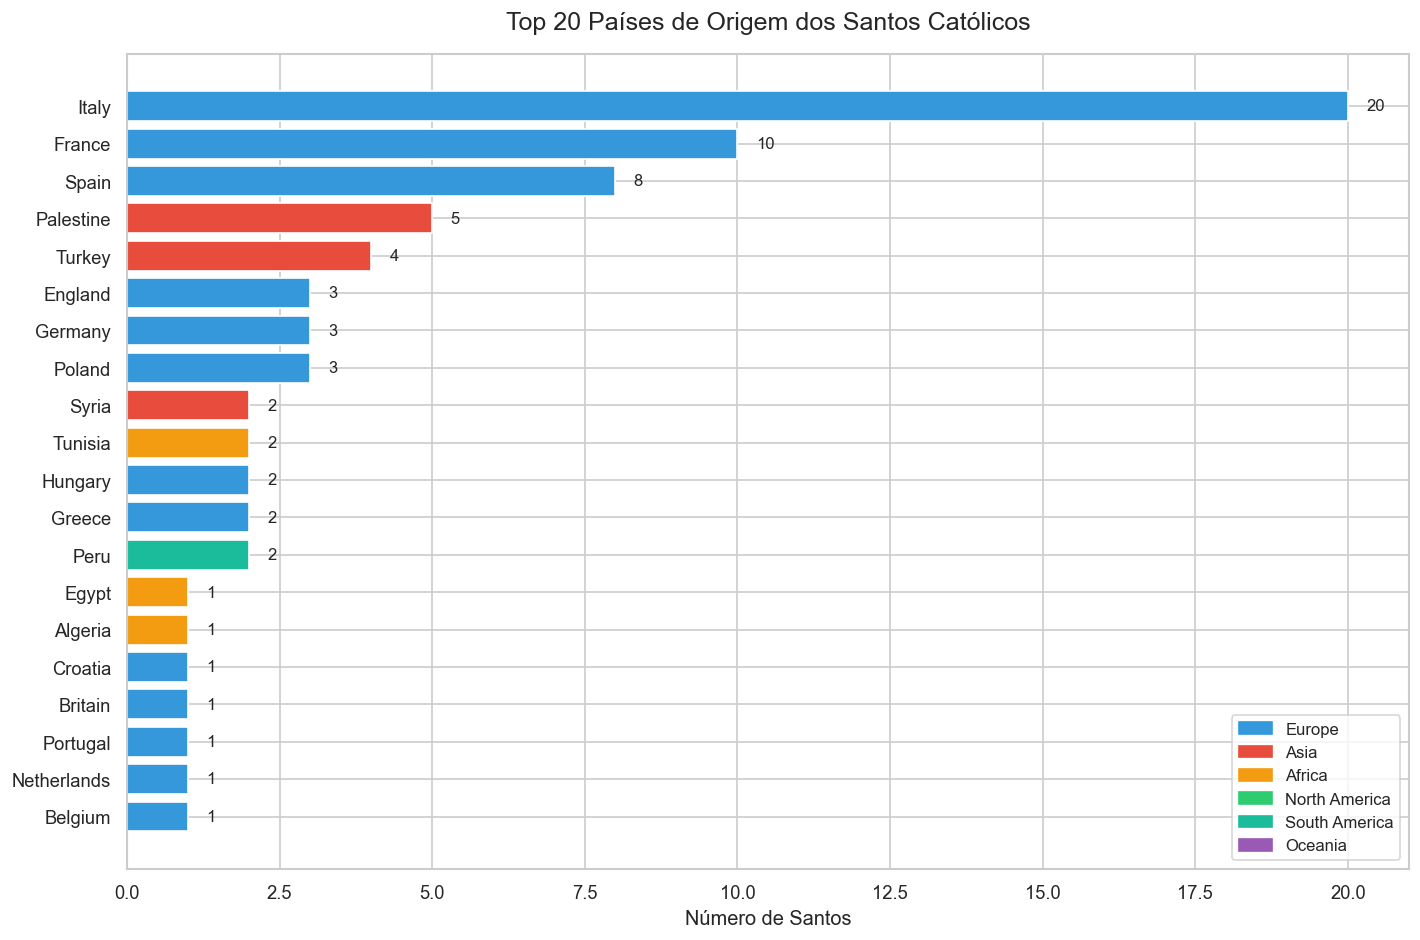

In [3]:
top20 = df['origin_country'].value_counts().head(20)

# Mapa país → continente para colorir barras
regioes = pd.read_csv(PROJECT_ROOT / 'data' / 'external' / 'world_regions.csv')
mapa_cont = dict(zip(regioes['country'].str.title(), regioes['continent']))
cores_cont = {
    'Europe': '#3498DB', 'Asia': '#E74C3C', 'Africa': '#F39C12',
    'North America': '#2ECC71', 'South America': '#1ABC9C', 'Oceania': '#9B59B6', 'Unknown': '#95A5A6'
}
cores_barras = [cores_cont.get(mapa_cont.get(p, 'Unknown'), '#95A5A6') for p in top20.index]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top20.index[::-1], top20.values[::-1], color=cores_barras[::-1])
ax.set_xlabel('Número de Santos')
ax.set_title('Top 20 Países de Origem dos Santos Católicos', fontsize=15, pad=15)

# Legenda de continentes
handles = [mpatches.Patch(color=c, label=cont) for cont, c in cores_cont.items() if cont != 'Unknown']
ax.legend(handles=handles, loc='lower right', fontsize=10)

# Rótulos de valor
for i, v in enumerate(top20.values[::-1]):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIGS / '03_top20_paises.png', bbox_inches='tight')
plt.show()

---
## Gráfico 3 — Santos Canonizados por Século (Time Series)

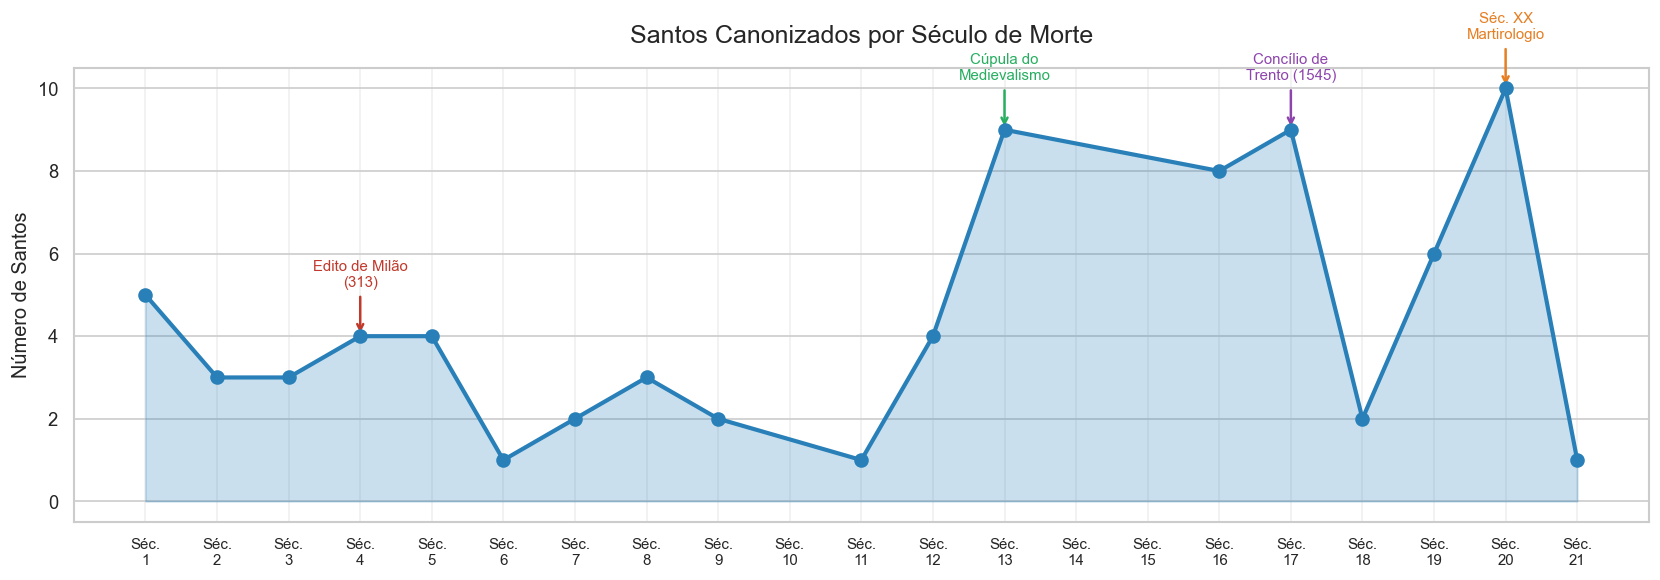

In [4]:
por_seculo = df.dropna(subset=['century_of_death'])['century_of_death'].value_counts().sort_index()
seculos = por_seculo.index.astype(int)
contagem = por_seculo.values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(seculos, contagem, color='#2980B9', linewidth=2.5, zorder=3)
ax.fill_between(seculos, contagem, alpha=0.25, color='#2980B9')
ax.scatter(seculos, contagem, color='#2980B9', s=60, zorder=4)

# Anotações históricas
anotacoes = {
    4: ('Edito de Milão\n(313)', '#C0392B'),
    13: ('Cúpula do\nMedievalismo', '#27AE60'),
    17: ('Concílio de\nTrento (1545)', '#8E44AD'),
    20: ('Séc. XX\nMartirologio', '#E67E22'),
}
for seculo, (texto, cor) in anotacoes.items():
    if seculo in seculos:
        y_val = por_seculo.get(seculo, 0)
        ax.annotate(texto, xy=(seculo, y_val), xytext=(seculo, y_val + max(contagem)*0.12),
                    ha='center', fontsize=9, color=cor,
                    arrowprops=dict(arrowstyle='->', color=cor, lw=1.5))

ax.set_xticks(range(int(min(seculos)), int(max(seculos))+1))
ax.set_xticklabels([f'Séc.\n{s}' for s in range(int(min(seculos)), int(max(seculos))+1)], fontsize=9)
ax.set_ylabel('Número de Santos')
ax.set_title('Santos Canonizados por Século de Morte', fontsize=15, pad=15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGS / '03_series_temporal.png', bbox_inches='tight')
plt.show()

---
## Gráfico 4 — Stacked Bar: Categorias por Século

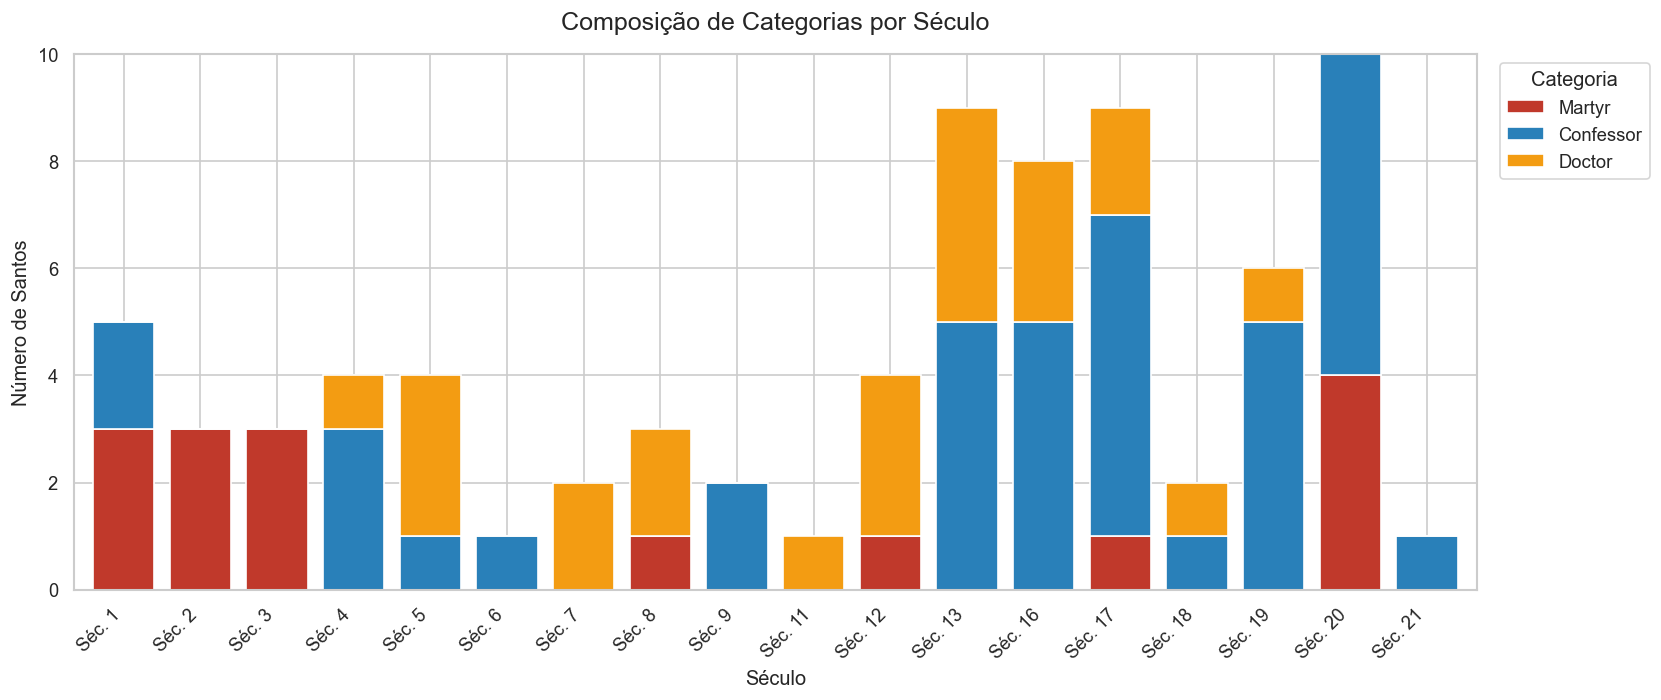

Igreja primitiva = mártires. Era moderna = confessores e doutores.


In [5]:
df_seculo = df.dropna(subset=['century_of_death']).copy()
df_seculo['century_of_death'] = df_seculo['century_of_death'].astype(int)

pivot = pd.crosstab(df_seculo['century_of_death'], df_seculo['category'])

# Garantir ordem das categorias
cats_ordem = [c for c in ['Martyr', 'Confessor', 'Doctor', 'Virgin', 'Other'] if c in pivot.columns]
pivot = pivot[cats_ordem]

ax = pivot.plot(
    kind='bar', stacked=True,
    color=[CORES[c] for c in cats_ordem],
    figsize=(14, 6), width=0.8
)
ax.set_xlabel('Século')
ax.set_ylabel('Número de Santos')
ax.set_title('Composição de Categorias por Século', fontsize=15, pad=15)
ax.set_xticklabels([f'Séc. {s}' for s in pivot.index], rotation=45, ha='right')
ax.legend(title='Categoria', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig(FIGS / '03_stacked_categorias.png', bbox_inches='tight')
plt.show()
print('Igreja primitiva = mártires. Era moderna = confessores e doutores.')

---
## Gráfico 5 — Heatmap: Século × Continente

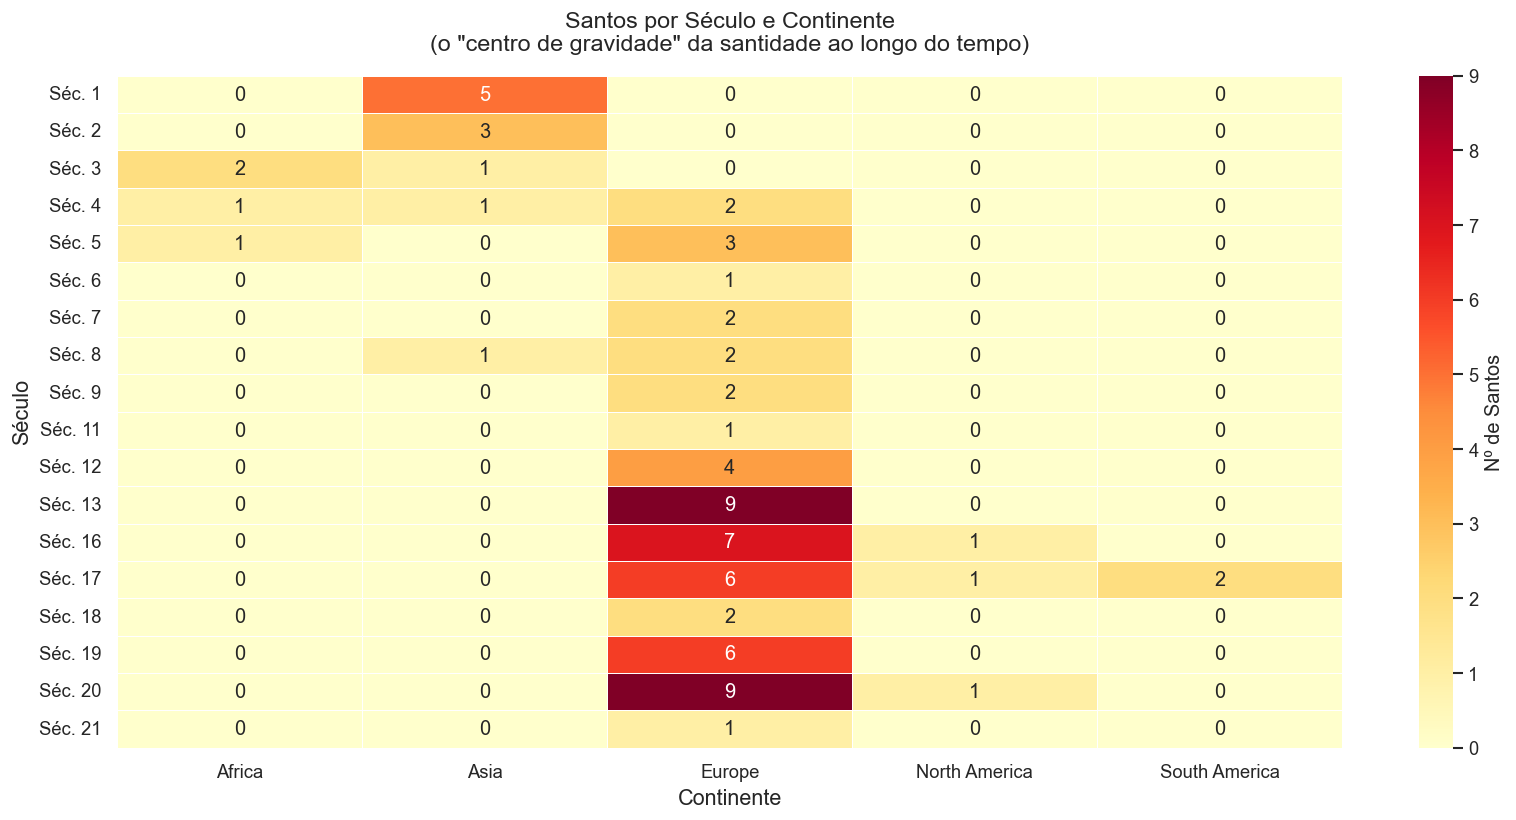

In [6]:
df_hm = df.dropna(subset=['century_of_death', 'continent']).copy()
df_hm['century_of_death'] = df_hm['century_of_death'].astype(int)
df_hm = df_hm[df_hm['continent'] != 'Unknown']

pivot_hm = pd.crosstab(df_hm['century_of_death'], df_hm['continent'])

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot_hm,
    annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Nº de Santos'}
)
ax.set_xlabel('Continente', fontsize=13)
ax.set_ylabel('Século', fontsize=13)
ax.set_title('Santos por Século e Continente\n(o "centro de gravidade" da santidade ao longo do tempo)', fontsize=14, pad=15)
ax.set_yticklabels([f'Séc. {y.get_text()}' for y in ax.get_yticklabels()], rotation=0)

plt.tight_layout()
plt.savefig(FIGS / '03_heatmap_seculo_continente.png', bbox_inches='tight')
plt.show()

---
## Gráfico 6 — Violin Plot: Anos até Canonização por Categoria

C:\Users\mateu\AppData\Local\Temp\ipykernel_36472\1478998287.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




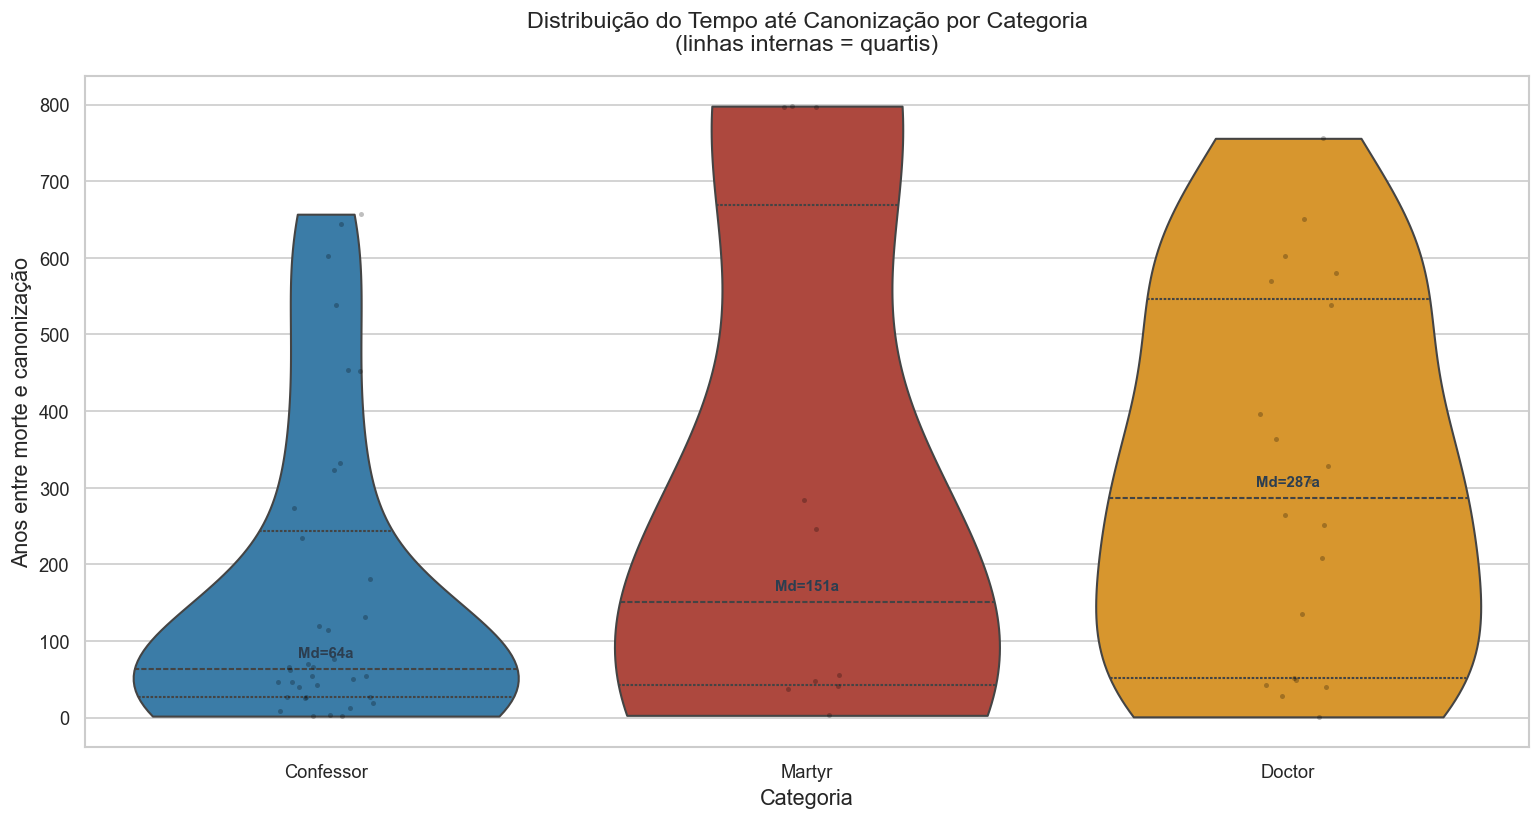

In [7]:
df_ytc = df.dropna(subset=['years_to_canonization', 'category']).copy()
df_ytc = df_ytc[df_ytc['years_to_canonization'] <= 800]  # excluir pré-canonização formal
df_ytc = df_ytc[df_ytc['years_to_canonization'] >= 0]

ordem_cat = df_ytc.groupby('category')['years_to_canonization'].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(13, 7))
sns.violinplot(
    data=df_ytc, x='category', y='years_to_canonization',
    order=ordem_cat, palette=CORES, inner='quartile',
    ax=ax, cut=0
)
sns.stripplot(
    data=df_ytc, x='category', y='years_to_canonization',
    order=ordem_cat, color='black', alpha=0.25, size=3, jitter=True, ax=ax
)

ax.set_xlabel('Categoria', fontsize=13)
ax.set_ylabel('Anos entre morte e canonização', fontsize=13)
ax.set_title('Distribuição do Tempo até Canonização por Categoria\n(linhas internas = quartis)', fontsize=14, pad=15)

# Medianas como texto
for i, cat in enumerate(ordem_cat):
    med = df_ytc[df_ytc['category'] == cat]['years_to_canonization'].median()
    ax.text(i, med + 15, f'Md={med:.0f}a', ha='center', fontsize=9, color='#2C3E50', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGS / '03_violin_ytc_categoria.png', bbox_inches='tight')
plt.show()

---
## Gráfico 7 — Box Plot: Anos até Canonização por Continente

C:\Users\mateu\AppData\Local\Temp\ipykernel_36472\1778693088.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




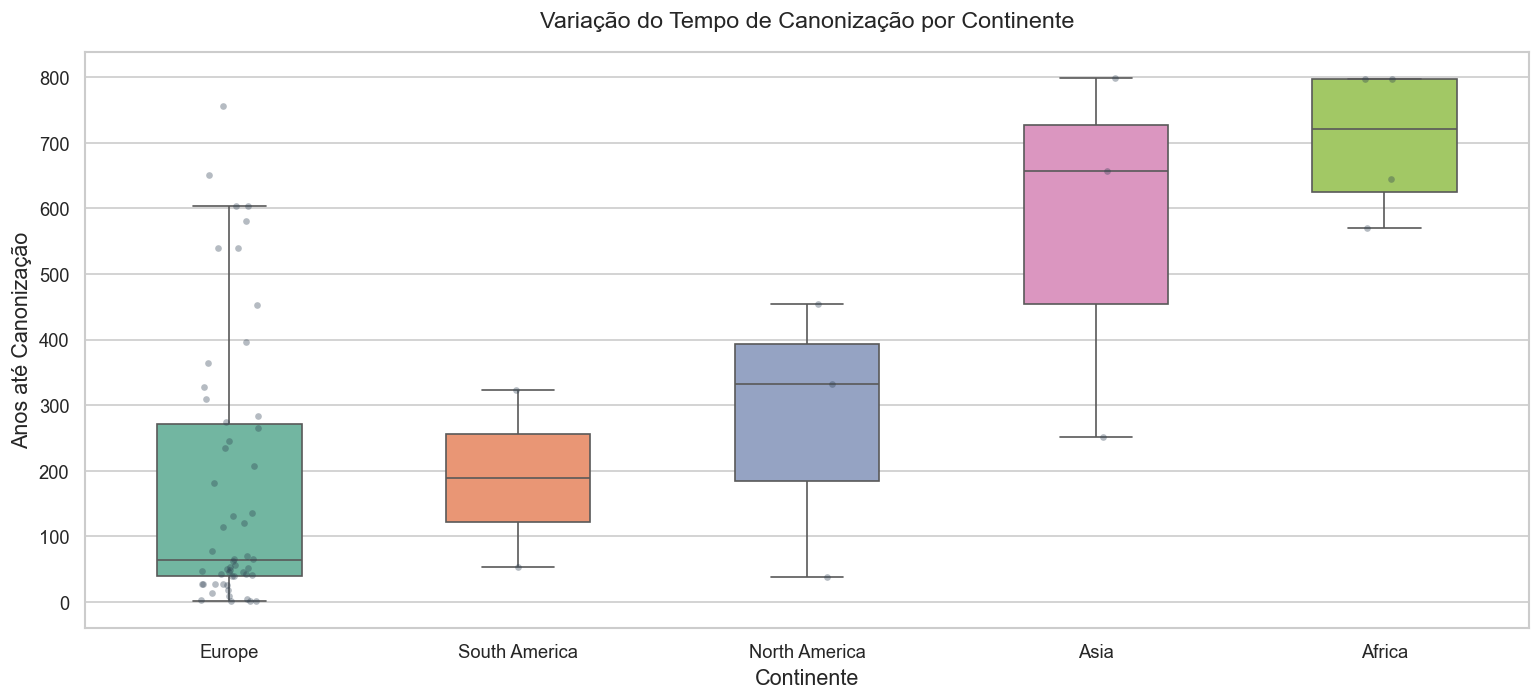

In [8]:
df_box = df.dropna(subset=['years_to_canonization', 'continent']).copy()
df_box = df_box[(df_box['years_to_canonization'] >= 0) & (df_box['years_to_canonization'] <= 800)]
df_box = df_box[df_box['continent'] != 'Unknown']

ordem_cont = df_box.groupby('continent')['years_to_canonization'].median().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=df_box, x='continent', y='years_to_canonization',
    order=ordem_cont, palette='Set2', ax=ax,
    width=0.5, fliersize=0
)
sns.stripplot(
    data=df_box, x='continent', y='years_to_canonization',
    order=ordem_cont, color='#2C3E50', alpha=0.35, size=4, jitter=True, ax=ax
)

ax.set_xlabel('Continente', fontsize=13)
ax.set_ylabel('Anos até Canonização', fontsize=13)
ax.set_title('Variação do Tempo de Canonização por Continente', fontsize=14, pad=15)

plt.tight_layout()
plt.savefig(FIGS / '03_boxplot_continente.png', bbox_inches='tight')
plt.show()

---
## Gráfico 8 — Scatter: Ano de Morte × Ano de Canonização

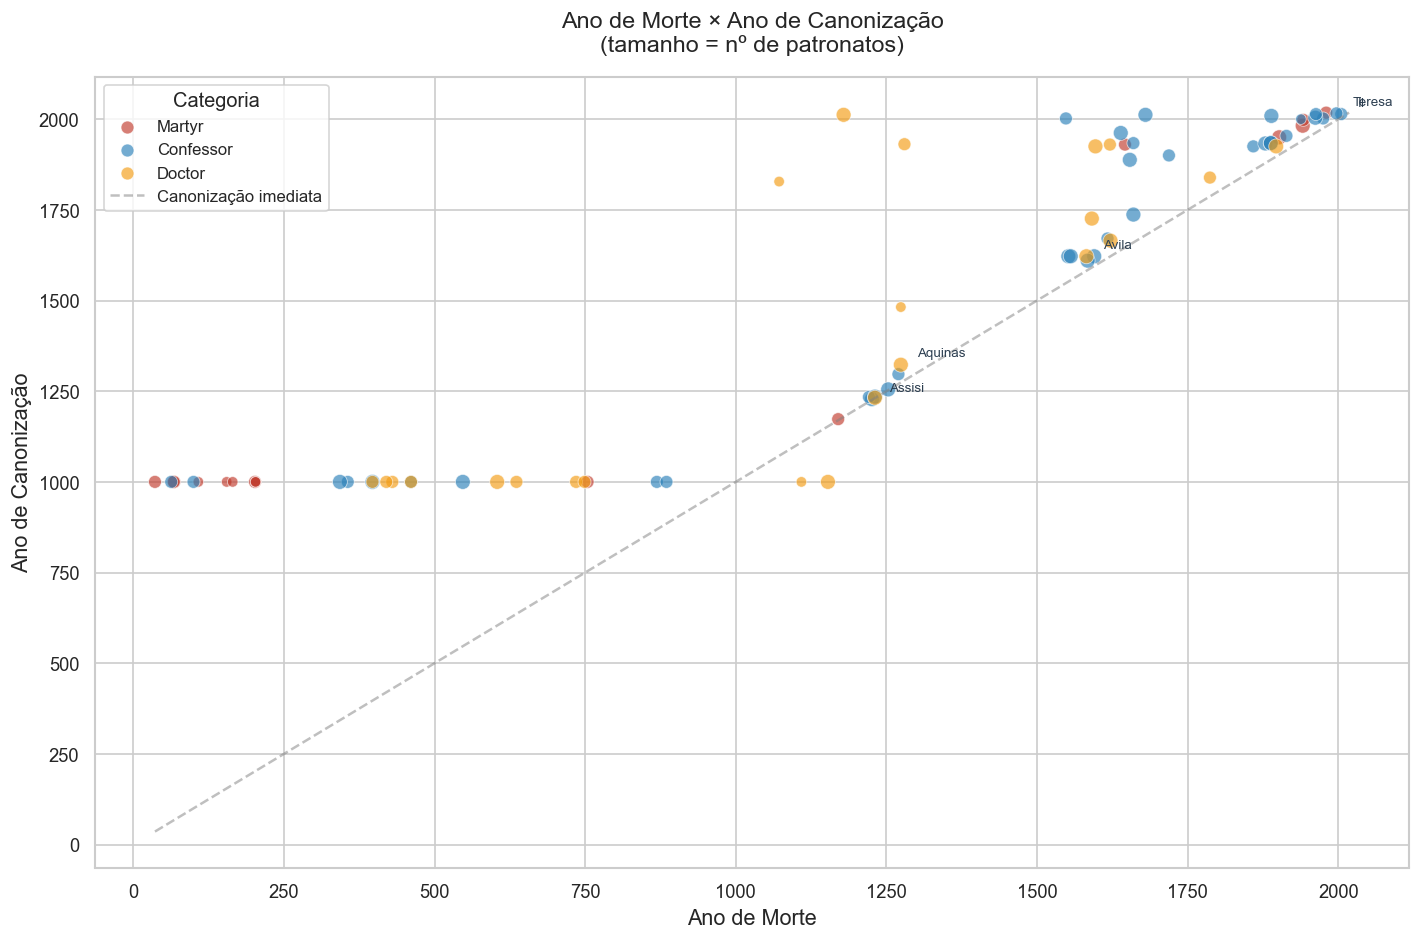

In [9]:
df_sc = df.dropna(subset=['death_year', 'canonization_year', 'category']).copy()

fig, ax = plt.subplots(figsize=(12, 8))

for cat in df_sc['category'].unique():
    sub = df_sc[df_sc['category'] == cat]
    ax.scatter(
        sub['death_year'], sub['canonization_year'],
        c=CORES.get(cat, '#95A5A6'), label=cat,
        alpha=0.65, s=sub['num_patron_topics'].fillna(1) * 20 + 20,
        edgecolors='white', linewidths=0.5
    )

# Linha diagonal: canonizado no mesmo ano da morte
lim_min = min(df_sc['death_year'].min(), df_sc['canonization_year'].min())
lim_max = max(df_sc['death_year'].max(), df_sc['canonization_year'].max())
ax.plot([lim_min, lim_max], [lim_min, lim_max], '--', color='gray', alpha=0.5, lw=1.5, label='Canonização imediata')

ax.set_xlabel('Ano de Morte', fontsize=13)
ax.set_ylabel('Ano de Canonização', fontsize=13)
ax.set_title('Ano de Morte × Ano de Canonização\n(tamanho = nº de patronatos)', fontsize=14, pad=15)
ax.legend(title='Categoria', fontsize=10)

# Anotar santos famosos
destaques = ['Thomas Aquinas', 'Francis of Assisi', 'Teresa of Avila', 'John Paul II', 'Mother Teresa']
for _, row in df_sc[df_sc['name'].isin(destaques)].iterrows():
    ax.annotate(row['name'].split()[-1], xy=(row['death_year'], row['canonization_year']),
                xytext=(10, 5), textcoords='offset points', fontsize=8, color='#2C3E50')

plt.tight_layout()
plt.savefig(FIGS / '03_scatter_morte_canonizacao.png', bbox_inches='tight')
plt.show()

---
## Gráfico 9 — Treemap: Santos por Ordem Religiosa

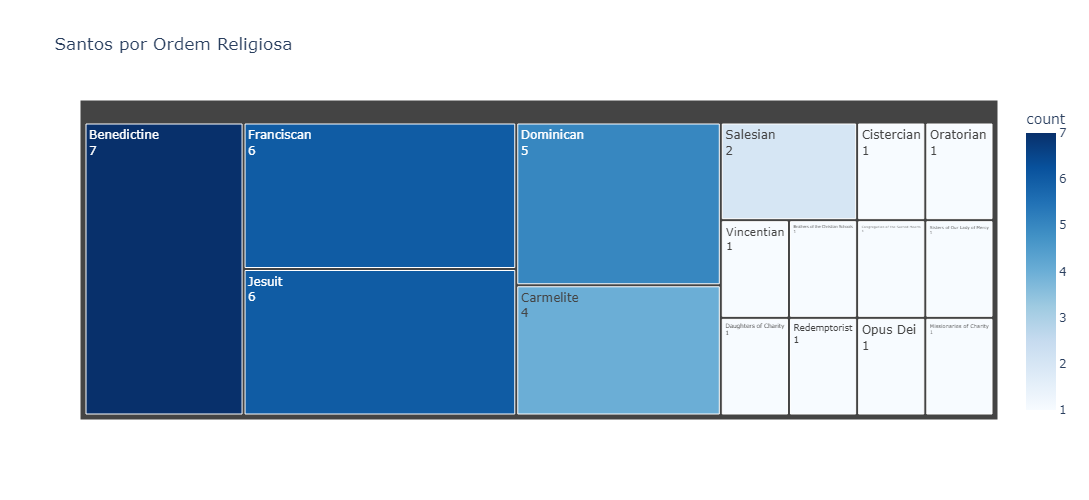

In [10]:
if 'religious_order' in df.columns:
    ordens = df[df['religious_order'] != 'None']['religious_order'].value_counts().reset_index()
    ordens.columns = ['order', 'count']

    fig = px.treemap(
        ordens,
        path=['order'], values='count',
        title='Santos por Ordem Religiosa',
        color='count',
        color_continuous_scale='Blues',
    )
    fig.update_traces(textinfo='label+value')
    fig.update_layout(height=500)
    fig.write_html(str(FIGS / '03_treemap_ordens.html'))
    fig.show()
else:
    print('Coluna religious_order não disponível.')

---
## Gráfico 10 — Patronatos Mais Comuns

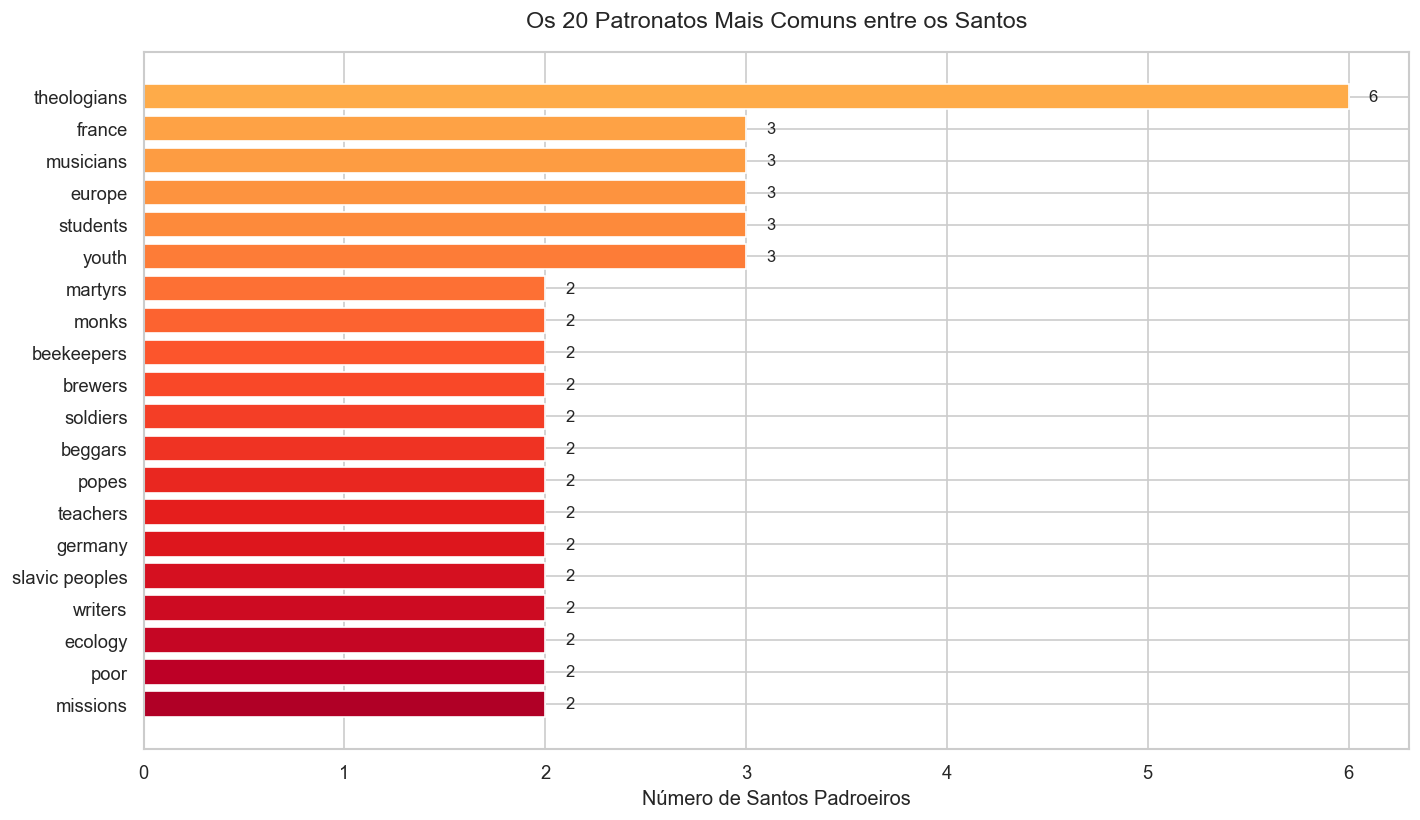

In [11]:
if 'patron_topics' in df.columns:
    # Explodir lista de patronatos
    patronatos = (
        df['patron_topics'].dropna()
        .str.lower()
        .str.split(',')
        .explode()
        .str.strip()
        .replace('', pd.NA)
        .dropna()
    )
    top_patronatos = patronatos.value_counts().head(20)

    fig, ax = plt.subplots(figsize=(12, 7))
    colors = plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_patronatos)))
    ax.barh(top_patronatos.index[::-1], top_patronatos.values[::-1], color=colors[::-1])
    ax.set_xlabel('Número de Santos Padroeiros')
    ax.set_title('Os 20 Patronatos Mais Comuns entre os Santos', fontsize=14, pad=15)
    for i, v in enumerate(top_patronatos.values[::-1]):
        ax.text(v + 0.1, i, str(v), va='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(FIGS / '03_patronatos.png', bbox_inches='tight')
    plt.show()
else:
    print('Coluna patron_topics não disponível.')

---
## Gráfico 11 — Polar Chart: Festas por Mês

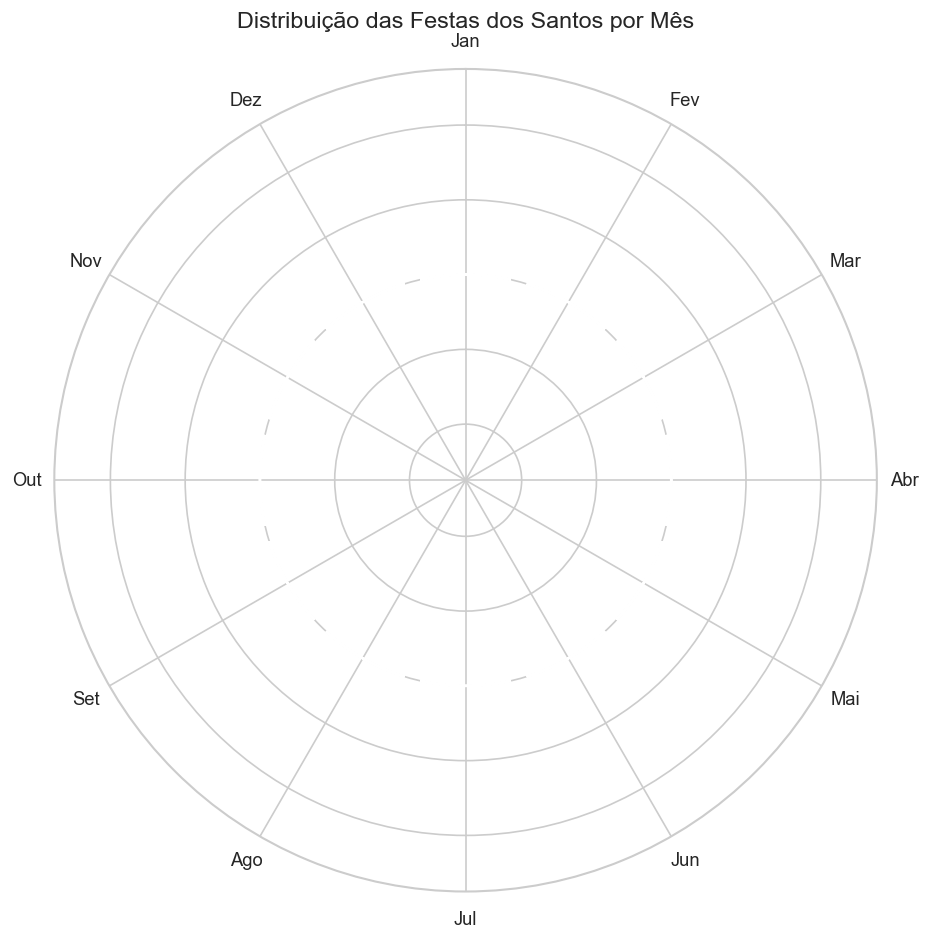

In [12]:
if 'feast_month' in df.columns:
    festas = df['feast_month'].dropna().astype(int).value_counts().sort_index()
    meses_nomes = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

    # Garantir todos os 12 meses
    festas = festas.reindex(range(1, 13), fill_value=0)

    theta = np.linspace(0, 2 * np.pi, 12, endpoint=False)
    largura = 2 * np.pi / 12

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
    bars = ax.bar(theta, festas.values, width=largura * 0.85, bottom=0, align='center',
                  color=plt.cm.Blues(np.linspace(0.4, 0.9, 12)), edgecolor='white', linewidth=1.5)

    ax.set_xticks(theta)
    ax.set_xticklabels(meses_nomes, fontsize=11)
    ax.set_yticklabels([])
    ax.set_title('Distribuição das Festas dos Santos por Mês', fontsize=14, pad=25)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)

    # Rótulos dentro das barras
    for t, v in zip(theta, festas.values):
        if v > 0:
            ax.text(t, v / 2, str(v), ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    plt.tight_layout()
    plt.savefig(FIGS / '03_polar_meses.png', bbox_inches='tight')
    plt.show()
else:
    print('Coluna feast_month não disponível.')

---
## Gráfico 12 — Correlation Heatmap

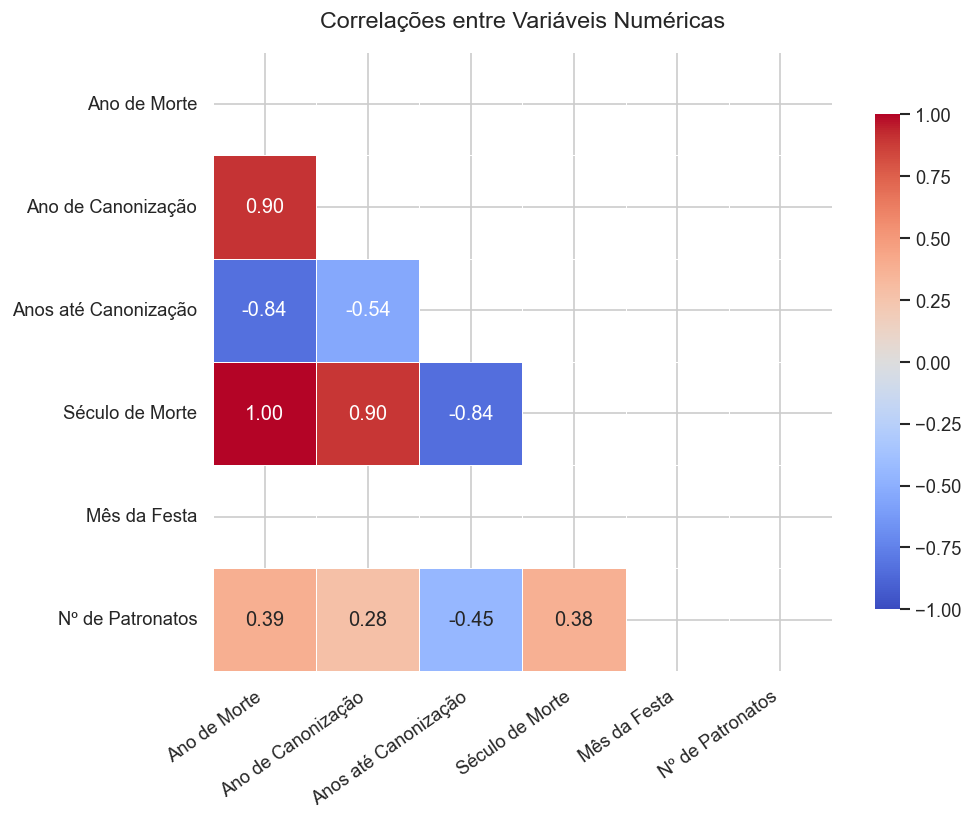

In [13]:
colunas_numericas = ['death_year', 'canonization_year', 'years_to_canonization',
                     'century_of_death', 'feast_month', 'num_patron_topics']
colunas_numericas = [c for c in colunas_numericas if c in df.columns]

df_num = df[colunas_numericas].apply(pd.to_numeric, errors='coerce')
corr = df_num.corr()

# Nomes em português para o gráfico
nomes_pt = {
    'death_year': 'Ano de Morte',
    'canonization_year': 'Ano de Canonização',
    'years_to_canonization': 'Anos até Canonização',
    'century_of_death': 'Século de Morte',
    'feast_month': 'Mês da Festa',
    'num_patron_topics': 'Nº de Patronatos',
}
corr.index = [nomes_pt.get(c, c) for c in corr.index]
corr.columns = [nomes_pt.get(c, c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlações entre Variáveis Numéricas', fontsize=14, pad=15)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(FIGS / '03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

---
## Gráfico 13 — Pair Plot

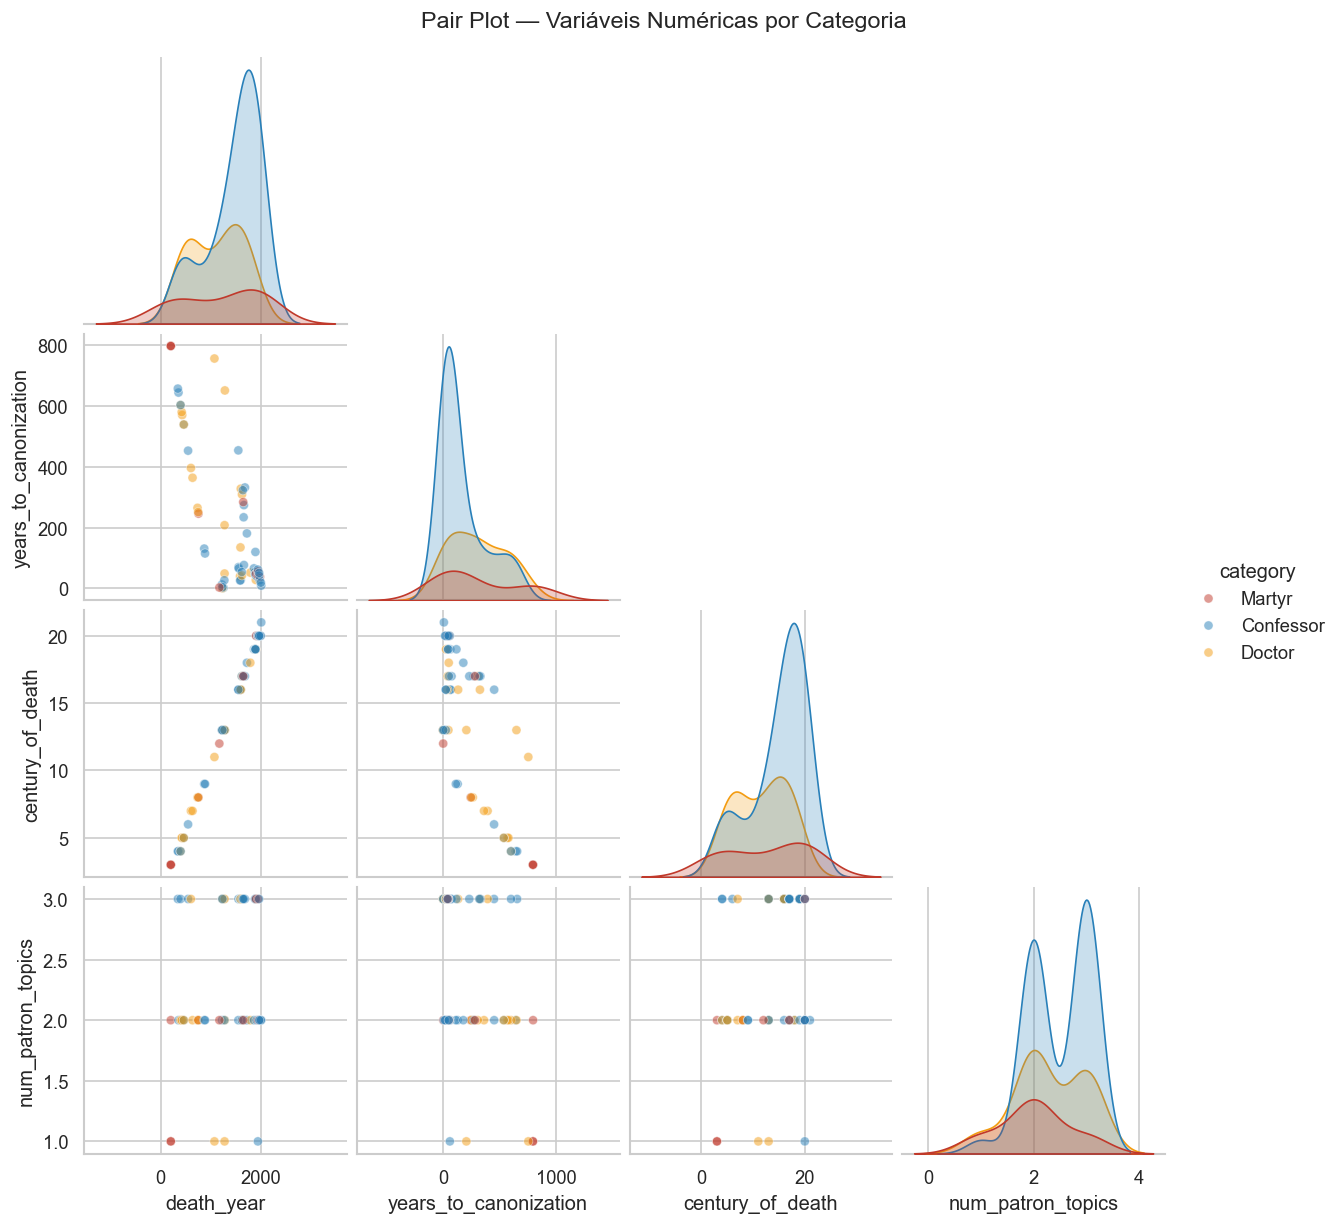

In [14]:
colunas_pair = ['death_year', 'years_to_canonization', 'century_of_death', 'num_patron_topics', 'category']
colunas_pair = [c for c in colunas_pair if c in df.columns]

df_pair = df[colunas_pair].dropna()
df_pair = df_pair[df_pair['years_to_canonization'].between(0, 800)]

g = sns.pairplot(
    df_pair,
    hue='category',
    palette=CORES,
    plot_kws={'alpha': 0.5, 's': 30},
    diag_kind='kde',
    corner=True
)
g.fig.suptitle('Pair Plot — Variáveis Numéricas por Categoria', y=1.02, fontsize=14)

plt.savefig(FIGS / '03_pairplot.png', bbox_inches='tight')
plt.show()

---
## Resumo dos Insights

Execute esta célula para imprimir os principais achados.

In [15]:
print('=== PRINCIPAIS INSIGHTS ===')
print(f'\n📍 País com mais santos: {df["origin_country"].value_counts().index[0]}')
print(f'🌍 Continente dominante: {df["continent"].value_counts().index[0]}')

if 'years_to_canonization' in df.columns:
    ytc = df[df['years_to_canonization'].between(0, 800)]
    print(f'\n⏱  Mediana geral de canonização: {ytc["years_to_canonization"].median():.0f} anos')
    print('  Por categoria:')
    for cat, med in ytc.groupby('category')['years_to_canonization'].median().sort_values().items():
        print(f'    {cat:<12}: {med:.0f} anos')

print(f'\n📅 Século mais produtivo: {df["century_of_death"].value_counts().index[0]:.0f}')

if 'religious_order' in df.columns:
    top_ordem = df[df['religious_order'] != 'None']['religious_order'].value_counts()
    if len(top_ordem) > 0:
        print(f'\n⛪ Ordem com mais santos: {top_ordem.index[0]} ({top_ordem.iloc[0]})')

print('\nGráficos salvos em outputs/figures/')

=== PRINCIPAIS INSIGHTS ===

📍 País com mais santos: Italy
🌍 Continente dominante: Europe

⏱  Mediana geral de canonização: 96 anos
  Por categoria:
    Confessor   : 64 anos
    Martyr      : 151 anos
    Doctor      : 287 anos

📅 Século mais produtivo: 20

⛪ Ordem com mais santos: Benedictine (7)

Gráficos salvos em outputs/figures/


## Próximo Passo

Abra o **Notebook 04 — ML: Clustering** para descobrir agrupamentos naturais entre os santos.